In [ ]:
# Parámetros a configurar:
import os
experiment_name = "command10"
task_name = "Command10"
cfg_dir = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_14/grid_hiperparametros/cfg_files"
path_resultados = "C:/Users/Teresa/Documents/GitHub/navsim/tmp/tmpTeresa/resultados_grid_command_v10"
isaaclab_bat = "C:/Users/Teresa/Desktop/RuralData/IsaacLab/IsaacLab/isaaclab.bat"
train_script = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/train.py"
id_task = f"Isaac-{task_name}-Aerotaxi-RANDOM" # luego se le añade el número de task con el guión (Isaac-Command2-Aerotaxi-RANDOM-34)
play_script = "C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/play.py"
num_iter = "1001"
num_steps_per_env = 100
powershell_script = os.path.join(cfg_dir, "run_all.ps1")

# el num_steps_per_env = 100 también está en el env, al final del todo, y deben tener el mismo valor
# Recuerda iniciar en el init todos los experimentos

In [2]:
import random
import os

# Si los directorios no existen (el último indicado), lo crea
os.makedirs(cfg_dir, exist_ok=True)
os.makedirs(path_resultados, exist_ok=True)
# Opciones de hiperparámetros
param_options = {
    "init_noise_std": [0.0, 0.1, 0.2, 0.5, 0.8, 1.0],
    "actor_hidden_dims": [[64, 64], [128, 128], [256, 256], [128, 64]],
    "critic_hidden_dims": [[64, 64], [128, 128], [256, 256]],
    "activation": ["relu", "tanh", "elu", "gelu"],
    "value_loss_coef": [0.5, 1.0, 2.0],
    "clip_param": [0.1, 0.2, 0.3],
    "entropy_coef": [0.0, 0.001, 0.01, 0.05],
    "num_learning_epochs": [4, 8, 12],
    "num_mini_batches": [2, 4, 8],
    "learning_rate": [5e-05, 1e-4, 3e-4, 1e-3, 3e-3],
    "gamma": [0.95, 0.98, 0.99],
    "lam": [0.90, 0.95, 0.97],
    "max_grad_norm": [0.5, 1.0, 2.0],
    "desired_kl": [0.005, 0.008, 0.01, 0.02],
}

num_trials = 35  # cantidad de configuraciones

cfg_files = []

for i in range(num_trials):
    run_name = f"ppo_random_{experiment_name}_{i+1}"
    sampled = {k: random.choice(v) for k, v in param_options.items()}

    # Convertir listas a string
    actor_dims = sampled["actor_hidden_dims"]
    critic_dims = sampled["critic_hidden_dims"]

    cfg_content = f"""
from isaaclab.utils import configclass
from isaaclab_rl.rsl_rl import RslRlOnPolicyRunnerCfg, RslRlPpoActorCriticCfg, RslRlPpoAlgorithmCfg

@configclass
class {task_name}PPORunnerCfg(RslRlOnPolicyRunnerCfg):
    num_steps_per_env = {num_steps_per_env} 
    max_iterations = {num_iter}
    save_interval = 100
    experiment_name = "{experiment_name}"
    run_name = "{run_name}"
    resume = False
    empirical_normalization = False
    csv_path_metrics = "{path_resultados}"
    callbacks = True
    policy = RslRlPpoActorCriticCfg(
        init_noise_std={sampled['init_noise_std']},
        actor_hidden_dims={actor_dims},
        critic_hidden_dims={critic_dims},
        activation="{sampled['activation']}",
    )
    algorithm = RslRlPpoAlgorithmCfg(
        value_loss_coef={sampled['value_loss_coef']},
        use_clipped_value_loss=True,
        clip_param={sampled['clip_param']},
        entropy_coef={sampled['entropy_coef']},
        num_learning_epochs={sampled['num_learning_epochs']},
        num_mini_batches={sampled['num_mini_batches']},
        learning_rate={sampled['learning_rate']},
        schedule="adaptive",
        gamma={sampled['gamma']},
        lam={sampled['lam']},
        desired_kl={sampled['desired_kl']},
        max_grad_norm={sampled['max_grad_norm']},
    )
"""
    cfg_path = os.path.join(cfg_dir, f"{run_name}_cfg.py")
    with open(cfg_path, "w") as f:
        f.write(cfg_content.strip())
    cfg_files.append((run_name, cfg_path))

# Crear archivo PowerShell para ejecutar todas las configuraciones
powershell_script = os.path.join(cfg_dir, "run_all.ps1")

num_envs =  [64, 128, 512, 1024, 2048, 4096, 8196] #número de entornos para train (paralelizados)

with open(powershell_script, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    j = 0
    for run_name, cfg_path in cfg_files:
        # Convertir path a módulo Python (reemplazar / y .py)
        num_envs_i = random.choice(num_envs)
        module_path = cfg_path.replace("/", ".").replace("\\", ".").replace(".py", "")
        f.write(f'Write-Host "Ejecutando {run_name}"\n')
        f.write(f'& "{isaaclab_bat}" -p "{train_script}" --task {id_task}-{j+1} --num_envs {num_envs_i} --headless \n\n')
        j += 1
print("Archivos de configuración generados y script PowerShell listo en:", powershell_script)

Archivos de configuración generados y script PowerShell listo en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_11/grid_hiperparametros/cfg_files\run_all.ps1


In [3]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_all.ps1

Ejecutando ppo_random_command9_11
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260304_094918.log
[0.115s] [ext: omni.kit.async_engine-0.0.3] startup
[0.222s] [ext: omni.metrics.core-0.0.3] startup
[0.224s] [ext: omni.client.lib-1.1.0] startup
[0.238s] [ext: omni.blobkey-1.1.2] startup
[0.240s] [ext: omni.stats-1.0.1] startup
[0.243s] [ext: omni

``Análisis de los datos``

In [4]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seed = 42
n=5

df_results_grid_actions = pd.read_csv(path_resultados+"/resultados_grid_PPO.csv")

In [5]:
def get_group(value):
    if f"_{experiment_name}" in value:
        return task_name

df_results_grid_actions["tarea"] = df_results_grid_actions["id_run_name"].apply(get_group)

In [6]:
df_copy = df_results_grid_actions.copy()
df_results_grid_actions.sample(n, random_state=seed)

,id_run_name,iteration,reward,max_reward,std_reward,num_envs_train,mean_Episode_Reward/rew_attitude_stability2,mean_Episode_Reward/rew_ang_vel_stability4,mean_Episode_Reward/rew_vel2,mean_Episode_Reward/rew_pos2,mean_Episode_Reward/rew_action_rate,mean_Episode_Termination/time_out,mean_Episode_Termination/below_min_altitude,mean_Episode_Termination/bad_attitude,mean_Episode_Termination/safety_shutdown,tarea
5,ppo_random_command9_11,500,214.500141,328.206085,44.437367,4096,1.857383,0.829990,2.711785,2.842500,-0.003122,0.914623,0.071945,0.013432,0.0,Command9
0,ppo_random_command9_11,0,7.708063,19.757578,2.761157,4096,0.056850,0.029685,0.002740,0.165859,-0.000006,0.024328,0.002256,0.420763,0.0,Command9
9,ppo_random_command9_11,900,244.107342,405.038574,68.110495,4096,1.847473,0.769266,2.818565,4.321825,-0.029492,0.940672,0.056879,0.002449,0.0,Command9
10,ppo_random_command9_11,1000,238.813181,383.384216,67.808381,4096,1.850815,0.785324,2.880291,4.226155,-0.042996,0.955523,0.042208,0.002270,0.0,Command9
2,ppo_random_command9_11,200,82.243783,199.531754,47.128178,4096,1.160263,0.583191,0.768819,0.401976,-0.000250,0.159092,0.208696,0.632212,0.0,Command9


In [7]:
df_results_grid_actions.set_index(['tarea','id_run_name'],inplace=True)
top5 = (
    df_results_grid_actions.groupby(level="tarea")
      .apply(lambda g: g.sort_values("reward", ascending=False).head(5))
)

# Eliminar el nivel adicional que introduce groupby+apply
top5.index = top5.index.droplevel(0)

top5

iteration      reward  max_reward  \
tarea    id_run_name                                                 
Command9 ppo_random_command9_11        800  244.396962  406.063293   
         ppo_random_command9_11        900  244.107342  405.038574   
         ppo_random_command9_11        700  238.892825  391.068420   
         ppo_random_command9_11       1000  238.813181  383.384216   
         ppo_random_command9_11        500  214.500141  328.206085   

                                 std_reward  num_envs_train  \
tarea    id_run_name                                          
Command9 ppo_random_command9_11   72.216836            4096   
         ppo_random_command9_11   68.110495            4096   
         ppo_random_command9_11   69.082464            4096   
         ppo_random_command9_11   67.808381            4096   
         ppo_random_command9_11   44.437367            4096   

                                 mean_Episode_Reward/rew_attitude_stability2  \
tarea    id_run_name                                                           
Command9 ppo_random_command9_11                                     1.848537   
         ppo_random_command9_11                                     1.847473   
         ppo_random_command9_11                                     1.846156   
         ppo_random_command9_11                                     1.850815   
         ppo_random_command9_11                                     1.857383   

                                 mean_Episode_Reward/rew_ang_vel_stability4  \
tarea    id_run_name                                                          
Command9 ppo_random_command9_11                                    0.775194   
         ppo_random_command9_11                                    0.769266   
         ppo_random_command9_11                                    0.778826   
         ppo_random_command9_11                                    0.785324   
         ppo_random_command9_11                                    0.829990   

                                 mean_Episode_Reward/rew_vel2  \
tarea    id_run_name                                            
Command9 ppo_random_command9_11                      2.835880   
         ppo_random_command9_11                      2.818565   
         ppo_random_command9_11                      2.814582   
         ppo_random_command9_11                      2.880291   
         ppo_random_command9_11                      2.711785   

                                 mean_Episode_Reward/rew_pos2  \
tarea    id_run_name                                            
Command9 ppo_random_command9_11                      4.222016   
         ppo_random_command9_11                      4.321825   
         ppo_random_command9_11                      3.848910   
         ppo_random_command9_11                      4.226155   
         ppo_random_command9_11                      2.842500   

                                 mean_Episode_Reward/rew_action_rate  \
tarea    id_run_name                                                   
Command9 ppo_random_command9_11                            -0.019827   
         ppo_random_command9_11                            -0.029492   
         ppo_random_command9_11                            -0.011770   
         ppo_random_command9_11                            -0.042996   
         ppo_random_command9_11                            -0.003122   

                                 mean_Episode_Termination/time_out  \
tarea    id_run_name                                                 
Command9 ppo_random_command9_11                           0.942017   
         ppo_random_command9_11                           0.940672   
         ppo_random_command9_11                           0.942364   
         ppo_random_command9_11                           0.955523   
         ppo_random_command9_11                           0.914623   

                                 mean_Episode_Termination/below_min_altitude 

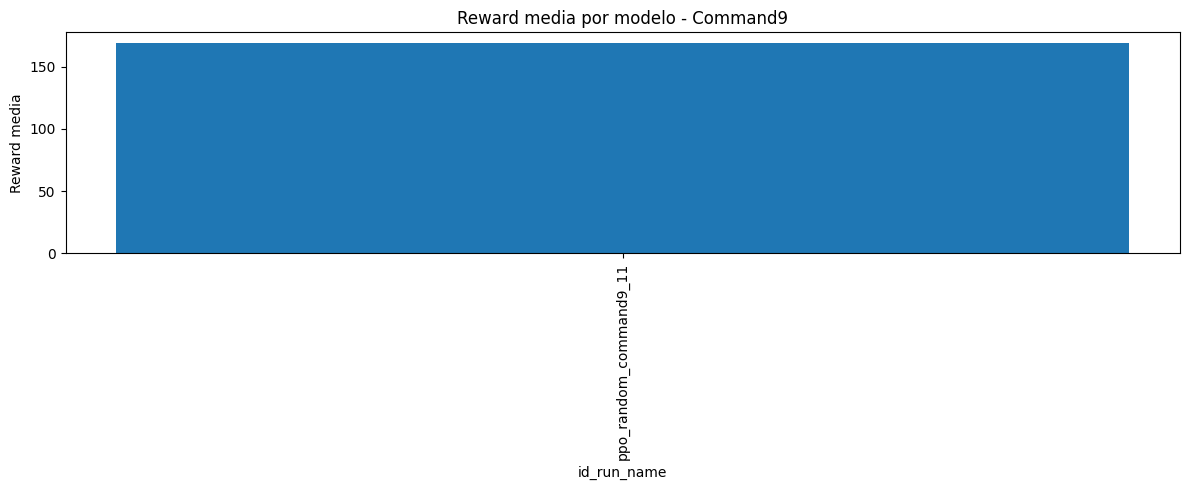

In [8]:
mean_rewards = df_results_grid_actions.groupby(["tarea", "id_run_name"])["reward"].mean()

for tarea, subdf in mean_rewards.groupby(level="tarea"):
    plt.figure(figsize=(12,5))
    
    # Convertir a DataFrame y resetear index para graficar
    plot_df = subdf.reset_index()
    plot_df = plot_df.sort_values("reward", ascending=False)
    
    plt.bar(plot_df["id_run_name"], plot_df["reward"])
    plt.title(f"Reward media por modelo - {tarea}")
    plt.xlabel("id_run_name")
    plt.ylabel("Reward media")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


In [9]:
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
top5_models

,iteration,reward,max_reward,std_reward,num_envs_train,mean_Episode_Reward/rew_attitude_stability2,mean_Episode_Reward/rew_ang_vel_stability4,mean_Episode_Reward/rew_vel2,mean_Episode_Reward/rew_pos2,mean_Episode_Reward/rew_action_rate,mean_Episode_Termination/time_out,mean_Episode_Termination/below_min_altitude,mean_Episode_Termination/bad_attitude,mean_Episode_Termination/safety_shutdown
id_run_name,,,,,,,,,,,,,,
ppo_random_command9_11,917,261.502937,429.041992,69.079971,4096,1.848173,0.775183,2.874317,4.206263,-0.031396,0.950165,0.047409,0.002426,0.0


Graficamos cómo fue el entrenamiento para los 5 mejores modelos según los callbacks:

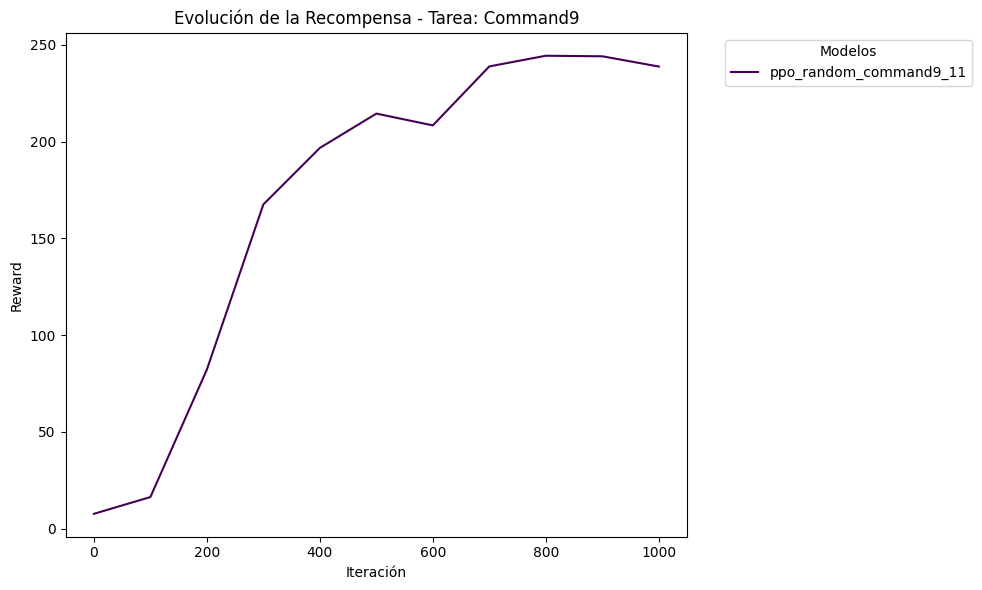

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Aseguramos que `top5_auc` tenga 'tarea' e 'id_run_name' como columnas, no solo en el índice
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")
top5_reset = top5_models.reset_index()
top5_reset["tarea"] = top5_reset["id_run_name"].apply(get_group)


# Convertir el índice jerárquico en columnas (para acceder a 'tarea' y 'id_run_name')
df_copy_reset = df_copy.reset_index()

# Unimos `top5_auc_reset` con `df_copy_reset` en las columnas comunes: 'tarea' y 'id_run_name'
merged_df = pd.merge(df_copy_reset, top5_reset[['tarea', 'id_run_name']], on=['tarea', 'id_run_name'], how='inner')

# Usamos una lista de colores para asignar un color diferente a cada modelo
colors = plt.cm.viridis(np.linspace(0, 1, len(merged_df['id_run_name'].unique())))

# Ahora, procedemos a graficar
for tarea, task_df in merged_df.groupby('tarea'):
    plt.figure(figsize=(10, 6))
    
    # Iteramos sobre los modelos (id_run_name) para esta tarea
    for i, (run_name, subdf) in enumerate(task_df.groupby('id_run_name')):
        # Graficamos la evolución de la recompensa a lo largo de las iteraciones
        plt.plot(subdf['iteration'], subdf['reward'], label=run_name, color=colors[i])
    
    plt.xlabel('Iteración')
    plt.ylabel('Reward')
    plt.title(f'Evolución de la Recompensa - Tarea: {tarea}')
    plt.legend(title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()



``Cojo los 5 modelos mejores de todos de los callbacks``

In [11]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")

powershell_script_test = os.path.join(cfg_dir, "run_tests.ps1")

with open(powershell_script_test, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        f.write(f'Write-Host "Ejecutando Test final para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 1 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')
        
print(f"Script de test generado en: {powershell_script_test}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests.ps1


### Test con 1 entorno

In [12]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests.ps1

Ejecutando Test final para Experimento 11...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260304_132316.log
2026-03-04T12:23:17Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-03-04T12:23:17Z s] [Warning] [carb] Acquiring non optional plugin interface which is not listed as depende

In [13]:
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")

In [14]:
df_rewards_play = pd.read_csv(path_resultados+'/rewards_play_PPO.csv')

In [15]:
df_rewards_play

,id_run_name,reward,max_reward,std,num_envs_test,checkpoint,mean_Episode_Reward/rew_attitude_stability2,mean_Episode_Reward/rew_ang_vel_stability4,mean_Episode_Reward/rew_vel2,mean_Episode_Reward/rew_pos2,mean_Episode_Reward/rew_action_rate,mean_Episode_Termination/time_out,mean_Episode_Termination/below_min_altitude,mean_Episode_Termination/bad_attitude,mean_Episode_Termination/safety_shutdown
0,ppo_random_command9_11,124.9072,124.9072,0.0,1,C:/Users/Teresa/Documents/GitHub/navsim/tmp/tm...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Test con 64 entornos

In [16]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")

powershell_script_test_2 = os.path.join(cfg_dir, "run_tests_2.ps1")

with open(powershell_script_test_2, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        f.write(f'Write-Host "Ejecutando Test final para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 64 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')
        
print(f"Script de test generado en: {powershell_script_test_2}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests_2.ps1


In [17]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test_2 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests_2.ps1

Ejecutando Test final para Experimento 11...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260304_132407.log
2026-03-04T12:24:07Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-03-04T12:24:08Z s] [Warning] [carb] Acquiring non optional plugin interface which is not listed as depen

#### Test con 256 entornos

In [18]:
import os
df_callbacks = pd.read_csv(path_resultados+"/reward_best_models.csv",index_col='id_run_name')
top5_models = df_callbacks.nlargest(5,columns="reward")

powershell_script_test_3 = os.path.join(cfg_dir, "run_tests_3.ps1")

with open(powershell_script_test_3, "w") as f:
    f.write("$ErrorActionPreference = 'Stop'\n\n")
    
    for run_id, row in top5_models.iterrows():
        # Extraemos el número del id (ej: de 'ppo_random_hover_4' sacamos '4')
        experiment_number = run_id.split('_')[-1]
        
        # Construimos la ruta exacta del checkpoint
        # Nota: Asegúrate de que path_resultados termine en / o usar os.path.join
        checkpoint_path = f"{path_resultados}/best_model_{run_id}_{int(row['num_envs_train'])}.pt"
        f.write(f'Write-Host "Ejecutando Test final para Experimento {experiment_number}..."\n')
        
        # Usamos el experiment_number extraído para la tarea (--task)
        # Se añaden flags típicos de play.py: --num_envs 1 y se quita --headless para ver el visualizador
        f.write(f'& "{isaaclab_bat}" -p "{play_script}" '
                f'--task {id_task}-{experiment_number} '
                f'--num_envs 256 '
                f' --headless '
                f'--checkpoint "{checkpoint_path}"\n\n')
        
print(f"Script de test generado en: {powershell_script_test_3}")


Script de test generado en: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests_3.ps1


In [19]:
# Ejecuta el entrenamiento de forma automática
# !powershell -ExecutionPolicy Bypass -File "{powershell_script}"
import subprocess
import sys

# Ruta al script que generaste
powershell_script_path = powershell_script_test_3 

print(f"Iniciando ejecución de: {powershell_script_path}\n")

# Ejecutamos el proceso capturando la salida en tiempo real
process = subprocess.Popen(
    ["powershell.exe", "-ExecutionPolicy", "Bypass", "-File", powershell_script_path],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT, # Redirigimos errores a la salida estándar para verlos
    text=True,
    bufsize=1
)

# Leemos la salida línea a línea conforme se genera
try:
    for line in process.stdout:
        print(line, end="") # Imprime la salida de PowerShell en la celda
        sys.stdout.flush()   # Fuerza a Jupyter a mostrar la línea inmediatamente
except KeyboardInterrupt:
    process.kill()
    print("\nEntrenamiento cancelado por el usuario.")

process.wait()
print("\n--- Todos los experimentos de test han finalizado ---")

Iniciando ejecución de: C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/aerotaxi/env_command/env_13/grid_hiperparametros/cfg_files\run_tests_3.ps1

Ejecutando Test final para Experimento 11...
[INFO] Using python from: C:\Users\Teresa\miniconda3\envs\env_isaaclab\python.exe
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: C:\Users\Teresa\miniconda3\envs\env_isaaclab\Lib\site-packages\isaaclab\apps\isaaclab.python.headless.kit
Loading user config located at: 'c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/data/Kit/Isaac-Sim/5.1/user.config.json'
[Info] [carb] Logging to file: c:/users/teresa/miniconda3/envs/env_isaaclab/lib/site-packages/isaacsim/kit/logs/Kit/Isaac-Sim/5.1/kit_20260304_132443.log
2026-03-04T12:24:44Z s] [Warning] [omni.usd_config.extension] Enable omni.materialx.libs extension to use MaterialX
2026-03-04T12:24:44Z s] [Warning] [carb] Acquiring non optional plugin interface which is not listed as depen

In [20]:
import pandas as pd

df_train = top5_models.copy()
if df_train.index.name == 'id_run_name':
    df_train = df_train.reset_index()

df_train = df_train.rename(columns={
    'reward': 'reward_train',
    'max_reward': 'max_reward_train',
    'std_reward': 'std_train'
})

df_test = df_rewards_play.copy()

df_test = pd.read_csv(path_resultados+'/rewards_play_PPO.csv')
df_test = df_test.rename(columns={
    'reward': 'reward_test',
    'max_reward': 'max_reward_test',
    'std': 'std_test'
})

df_final = pd.merge(
    df_train[['id_run_name', 'num_envs_train', 'reward_train', 'max_reward_train', 'std_train', 'iteration']], 
    df_test[['id_run_name', 'num_envs_test', 'reward_test', 'max_reward_test', 'std_test', 'checkpoint']], 
    on='id_run_name', 
    how='inner'
)

column_order = [
    'id_run_name',
    'num_envs_train',
    'num_envs_test',
    'reward_train', 'reward_test', 
    'max_reward_train', 'max_reward_test', 
    'std_train', 'std_test',
    'iteration'
]
df_final = df_final[column_order]

df_final = df_final.sort_values(by='id_run_name', ascending=False)

In [21]:
df_rewards_play = df_final.sort_values(by="id_run_name",ascending=False)
df_rewards_play = df_rewards_play.reset_index().drop(columns='index')

df_final = df_rewards_play.copy()

df_final['diff_rw_test_train'] = df_final['reward_test'] - df_final['reward_train']

df_final['diferencia(%)'] = (df_final['diff_rw_test_train'] / df_final['reward_train'].abs()) * 100

df_final['diferencia(%)'] = df_final['diferencia(%)'].apply(lambda x: f"{x:+.2f}%")

df_final

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
0,ppo_random_command9_11,4096,1,261.502937,124.907200,429.041992,124.907200,69.079971,0.000000,917,-136.595737,-52.23%
1,ppo_random_command9_11,4096,64,261.502937,102.012420,429.041992,269.005353,69.079971,64.305084,917,-159.490517,-60.99%
2,ppo_random_command9_11,4096,256,261.502937,103.153701,429.041992,318.718204,69.079971,67.180449,917,-158.349236,-60.55%


Pruebas con un solo entorno: Vemos cómo se comporta la política para un único agente en una prueba aleatoria.

In [22]:
df_final[df_final['num_envs_test'] == 1].sort_values(by='reward_test',ascending=False)

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
0,ppo_random_command9_11,4096,1,261.502937,124.9072,429.041992,124.9072,69.079971,0.0,917,-136.595737,-52.23%


``Interpretación``: Vemos que el modelo 38 se ha estampado en la prueba aleatoria, así que ese modelo no debería usarse para ninguna transferencia real.

Pruebas con varios entornos: Vemos cómo se comporta la política en múltiples entornos (varias pruebas simuladas en paralelo), teniendo en cuenta cuál es la desviación de cada uno en test, lo que nos permite inferir si la recompensa es estable para todas las pruebas.

In [23]:
df_final[df_final['num_envs_test'] != 1].sort_values(by='std_test',ascending=True).reset_index().drop(columns="index")

,id_run_name,num_envs_train,num_envs_test,reward_train,reward_test,max_reward_train,max_reward_test,std_train,std_test,iteration,diff_rw_test_train,diferencia(%)
0,ppo_random_command9_11,4096,64,261.502937,102.012420,429.041992,269.005353,69.079971,64.305084,917,-159.490517,-60.99%
1,ppo_random_command9_11,4096,256,261.502937,103.153701,429.041992,318.718204,69.079971,67.180449,917,-158.349236,-60.55%


pruebas:

C:/Users/Teresa/Desktop/RuralData/IsaacLab/IsaacLab/isaaclab.bat -p C:/Users/Teresa/Documents/GitHub/navsim/isaac_lab/rl_v5_1_0/rsl_rl/train.py --task Isaac-Command5-Aerotaxi-RANDOM-11 --num_envs 8196 --headless 